#A) Business Background

##Business Requirement and Objective

The "Video_Game_Sales_as_of_2015" data set collects information about video game sales and reviews. Each entry in the dataset includes details such as game name, platform, release year, genre, publisher, sales in North America, Europe, Japan, other regions, and global sales. Additional information consists of critic scores and counts, user scores and counts, and game ratings. This data set provides a comprehensive picture of the performance and reception of video games in the global market, with a focus on sales and critical evaluation as well as users.

Our goal is to analyze this data to identify the causes of the decline in video game sales globally in the last three years. We chose to analyze this issue because that year was the peak of the lowest decline in history. We hope that the results of our analysis can resolve the problems that occur and provide solutions. so that similar decline problems do not occur again

####**Video_Game_Sales Dataset (spreadsheet):**
* https://docs.google.com/spreadsheets/d/1ftXP8ly5G_r6-sR5VWBmOR8kScv5cO98YFvTPJ4XSAo/edit#gid=1320882815



#B) Data Preparation

## Import Library

In [ ]:
import pandas as pd                 # Library used for working with data sets and perform data analysis.
import numpy as np                  # To perform mathematical operasion and statistics
from datetime import datetime       # Used to perform dates and time manipulation
import seaborn as sns               # To perform data visualization
import matplotlib.pyplot as plt     # To perform data visualization

## Import Dataset

### Video Game (Spreadsheet)

In [ ]:
#Import dataset from spreadsheet
sheet_url = 'https://docs.google.com/spreadsheets/d/1ftXP8ly5G_r6-sR5VWBmOR8kScv5cO98YFvTPJ4XSAo/edit#gid=1320882815'
sheet_url_replace = sheet_url.replace('/edit#gid=', '/export?format=csv&gid=') #to convert the spreadsheet format into csv

print(sheet_url_replace) #To show the link to csv

df_video_game_og = pd.read_csv(sheet_url_replace) #to load/read the csv into pandas dataframe
df_video_game_og.head(10) #Show only first 5 rows (To see how the dataset lookslike without)

https://docs.google.com/spreadsheets/d/1ftXP8ly5G_r6-sR5VWBmOR8kScv5cO98YFvTPJ4XSAo/export?format=csv&gid=1320882815


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Alienators: Evolution Continues,GBA,2001,Action,Activision,0.03,0.01,0.00,0.00,0.03,54.0,4.0,NaN,NaN,E
1,Army Men World War: Final Front,PS,2001,Action,3DO,0.24,0.17,0.00,0.03,0.44,NaN,NaN,NaN,NaN,NaN
2,Army Men World War: Team Assault,PS,2001,Action,3DO,0.06,0.04,0.00,0.01,0.10,NaN,NaN,NaN,NaN,NaN
3,Army Men: Green Rogue,PS2,2001,Action,3DO,0.06,0.05,0.00,0.02,0.13,39.0,13.0,3.8,4.0,T
4,Army Men: Green Rogue,PS,2001,Action,3DO,0.04,0.02,0.00,0.00,0.07,NaN,NaN,NaN,NaN,NaN
5,Azurik: Rise of Perathia,X,2001,Action,Microsoft Game Studios,0.18,0.05,0.00,0.01,0.24,52.0,26.0,8.5,14.0,T
6,Devil May Cry,PS2,2001,Action,Capcom,1.36,0.86,0.64,0.13,2.99,94.0,37.0,8.5,467.0,M
7,Dynasty Warriors 3,PS2,2001,Action,THQ,0.53,0.16,1.07,0.10,1.87,78.0,17.0,9.1,90.0,T
8,E.T. The Extra-Terrestrial,GBA,2001,Action,NewKidCo,0.01,0.00,0.00,0.00,0.01,46.0,4.0,2.2,23.0,E
9,Extermination,PS2,2001,Action,Sony Computer Entertainment,0.21,0.16,0.12,0.05,0.55,67.0,19.0,7.8,19.0,M


In [ ]:
df_video_game_og.head(10) #Show only first 5 rows (To see how the dataset lookslike without)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Alienators: Evolution Continues,GBA,2001,Action,Activision,0.03,0.01,0.00,0.00,0.03,54.0,4.0,NaN,NaN,E
1,Army Men World War: Final Front,PS,2001,Action,3DO,0.24,0.17,0.00,0.03,0.44,NaN,NaN,NaN,NaN,NaN
2,Army Men World War: Team Assault,PS,2001,Action,3DO,0.06,0.04,0.00,0.01,0.10,NaN,NaN,NaN,NaN,NaN
3,Army Men: Green Rogue,PS2,2001,Action,3DO,0.06,0.05,0.00,0.02,0.13,39.0,13.0,3.8,4.0,T
4,Army Men: Green Rogue,PS,2001,Action,3DO,0.04,0.02,0.00,0.00,0.07,NaN,NaN,NaN,NaN,NaN
5,Azurik: Rise of Perathia,X,2001,Action,Microsoft Game Studios,0.18,0.05,0.00,0.01,0.24,52.0,26.0,8.5,14.0,T
6,Devil May Cry,PS2,2001,Action,Capcom,1.36,0.86,0.64,0.13,2.99,94.0,37.0,8.5,467.0,M
7,Dynasty Warriors 3,PS2,2001,Action,THQ,0.53,0.16,1.07,0.10,1.87,78.0,17.0,9.1,90.0,T
8,E.T. The Extra-Terrestrial,GBA,2001,Action,NewKidCo,0.01,0.00,0.00,0.00,0.01,46.0,4.0,2.2,23.0,E
9,Extermination,PS2,2001,Action,Sony Computer Entertainment,0.21,0.16,0.12,0.05,0.55,67.0,19.0,7.8,19.0,M


#C) Data Cleaning

Steps to do :
* Treating missing values
* Check Duplicates, retain only the first record
* Check data & convert data types
* Check typos

### Video Game

In [ ]:
#Make a copy of the original data for data cleaning
df_video_game_dc = df_video_game_og.copy()

In [ ]:
df_video_game_dc.head() #Showing 5 data records

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Alienators: Evolution Continues,GBA,2001,Action,Activision,0.03,0.01,0.0,0.00,0.03,54.0,4.0,NaN,NaN,E
1,Army Men World War: Final Front,PS,2001,Action,3DO,0.24,0.17,0.0,0.03,0.44,NaN,NaN,NaN,NaN,NaN
2,Army Men World War: Team Assault,PS,2001,Action,3DO,0.06,0.04,0.0,0.01,0.10,NaN,NaN,NaN,NaN,NaN
3,Army Men: Green Rogue,PS2,2001,Action,3DO,0.06,0.05,0.0,0.02,0.13,39.0,13.0,3.8,4.0,T
4,Army Men: Green Rogue,PS,2001,Action,3DO,0.04,0.02,0.0,0.00,0.07,NaN,NaN,NaN,NaN,NaN


####Check Data Type

In [ ]:
df_video_game_dc.shape #Check how much column and rows

(14427, 15)

In [ ]:
df_video_game_dc.info() #Check table info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14427 entries, 0 to 14426
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             14427 non-null  object 
 1   Platform         14427 non-null  object 
 2   Year_of_Release  14427 non-null  int64  
 3   Genre            14427 non-null  object 
 4   Publisher        14427 non-null  object 
 5   NA_Sales         14427 non-null  float64
 6   EU_Sales         14427 non-null  float64
 7   JP_Sales         14427 non-null  float64
 8   Other_Sales      14427 non-null  float64
 9   Global_Sales     14427 non-null  float64
 10  Critic_Score     7818 non-null   float64
 11  Critic_Count     7818 non-null   float64
 12  User_Score       7293 non-null   float64
 13  User_Count       7293 non-null   float64
 14  Rating           9661 non-null   object 
dtypes: float64(9), int64(1), object(5)
memory usage: 1.7+ MB


Mengganti Dtype pada Critic_Score, Critic_Count, User_Score dan User_Count menjadi int64

In [ ]:
df_video_game_dc['Critic_Score'] = pd.to_numeric(df_video_game_dc['Critic_Score'], errors='coerce').fillna(0).astype(int)

# Mengganti nilai non-numeric dengan NaN, dan mengonversi ke integer setelah itu
df_video_game_dc['Critic_Count'] = pd.to_numeric(df_video_game_dc['Critic_Count'], errors='coerce').fillna(0).astype(int)

# Mengganti nilai non-numeric dengan NaN, dan mengonversi ke integer setelah itu
df_video_game_dc['User_Score'] = pd.to_numeric(df_video_game_dc['User_Score'], errors='coerce').fillna(0).astype(int)

# Mengganti nilai non-numeric dengan NaN, dan mengonversi ke integer setelah itu
df_video_game_dc['User_Count'] = pd.to_numeric(df_video_game_dc['User_Count'], errors='coerce').fillna(0).astype(int)

In [ ]:
df_video_game_dc.info() #Check table info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14427 entries, 0 to 14426
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             14427 non-null  object 
 1   Platform         14427 non-null  object 
 2   Year_of_Release  14427 non-null  int64  
 3   Genre            14427 non-null  object 
 4   Publisher        14427 non-null  object 
 5   NA_Sales         14427 non-null  float64
 6   EU_Sales         14427 non-null  float64
 7   JP_Sales         14427 non-null  float64
 8   Other_Sales      14427 non-null  float64
 9   Global_Sales     14427 non-null  float64
 10  Critic_Score     14427 non-null  int64  
 11  Critic_Count     14427 non-null  int64  
 12  User_Score       14427 non-null  int64  
 13  User_Count       14427 non-null  int64  
 14  Rating           9661 non-null   object 
dtypes: float64(5), int64(5), object(5)
memory usage: 1.7+ MB


Data Types telah berhasil di ubah menjadi int64

In [ ]:
df_video_game_dc.isnull().sum() #Check how much null values exist

Name                  0
Platform              0
Year_of_Release       0
Genre                 0
Publisher             0
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score          0
Critic_Count          0
User_Score            0
User_Count            0
Rating             4766
dtype: int64

In [ ]:
df_video_game_dc['Global_Sales'].dtype #Check the datatype

dtype('float64')

#### Check for values and Typo



In [ ]:
df_video_game_dc.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Rating'],
      dtype='object')

In [ ]:
#Checking the values for Genre

df_video_game_dc['Genre'].value_counts()

Action          3003
Sports          1945
Misc            1623
Role-Playing    1268
Adventure       1267
Shooter         1111
Racing          1018
Simulation       798
Platform         697
Fighting         618
Strategy         572
Puzzle           507
Name: Genre, dtype: int64

In [ ]:
df_video_game_dc['Platform'].value_counts()

DS      2248
PS2     2124
Wii     1356
PS3     1322
PSP     1302
X360    1283
PC      1005
GBA      843
X        832
GC       563
3DS      492
PSV      378
PS4      230
XOne     161
WiiU     136
PS       117
N64       11
DC        11
G         10
WS         3
Name: Platform, dtype: int64

Recommendation :

Option :
  1.
  2.

Here we just exclude the column

In [ ]:
#Checking the values for Genre
df_video_game_dc[df_video_game_dc.columns[3]].value_counts()

In [ ]:
#Checking the value
df_video_game_dc[df_video_game_dc.columns[4]].value_counts()    #Check count of every unique values

#### Treat Missing & Irrelevant Values

In [ ]:
# Check columns
df_video_game_dc.columns

In [ ]:
#Confirm whether null data still exist
df_video_game_dc.isna().sum()

In [ ]:
df_video_game_dc.shape   #Check the data we have

Creating a bin for the emp_length

In [ ]:
df_video_game_dc['Name'].value_counts()    #Check the unique values and the counts

####Check Duplicates

In [ ]:
#Check the duplicate
df_video_game_dc[df_video_game_dc['Name'].duplicated()]

#D) EDA

In [ ]:
#Preparing a copy of df_clean for EDA
df_eda = df_video_game_dc.copy()
df_eda.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Alienators: Evolution Continues,GBA,2001,Action,Activision,0.03,0.01,0.0,0.00,0.03,54,4,0,0,E
1,Army Men World War: Final Front,PS,2001,Action,3DO,0.24,0.17,0.0,0.03,0.44,0,0,0,0,NaN
2,Army Men World War: Team Assault,PS,2001,Action,3DO,0.06,0.04,0.0,0.01,0.10,0,0,0,0,NaN
3,Army Men: Green Rogue,PS2,2001,Action,3DO,0.06,0.05,0.0,0.02,0.13,39,13,3,4,T
4,Army Men: Green Rogue,PS,2001,Action,3DO,0.04,0.02,0.0,0.00,0.07,0,0,0,0,NaN


In [ ]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14427 entries, 0 to 14426
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             14427 non-null  object 
 1   Platform         14427 non-null  object 
 2   Year_of_Release  14427 non-null  int64  
 3   Genre            14427 non-null  object 
 4   Publisher        14427 non-null  object 
 5   NA_Sales         14427 non-null  float64
 6   EU_Sales         14427 non-null  float64
 7   JP_Sales         14427 non-null  float64
 8   Other_Sales      14427 non-null  float64
 9   Global_Sales     14427 non-null  float64
 10  Critic_Score     14427 non-null  int64  
 11  Critic_Count     14427 non-null  int64  
 12  User_Score       14427 non-null  int64  
 13  User_Count       14427 non-null  int64  
 14  Rating           9661 non-null   object 
dtypes: float64(5), int64(5), object(5)
memory usage: 1.7+ MB


##Descriptive statistics:
* Apa saja tren yang ada dalam penjualan video game
* bagaimana faktor-faktor seperti wilayah, genre, platform, tahun rilis, memainkan peran penting dalam pasar yang terus berubah ini selama bertahun-tahun"
* Bagaimana Meningkatkan Global sales



### Descriptive information about numeric variable

In [ ]:
df_eda.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Year_of_Release,14427.0,2007.988563,3.726985,2001.00,2005.00,2008.00,2011.00,2015.00
NA_Sales,14427.0,0.239136,0.713339,0.00,0.00,0.07,0.22,41.36
EU_Sales,14427.0,0.139641,0.511040,0.00,0.00,0.02,0.10,28.96
JP_Sales,14427.0,0.052964,0.243583,0.00,0.00,0.00,0.02,6.50
Other_Sales,14427.0,0.049445,0.198379,0.00,0.00,0.01,0.03,10.57
Global_Sales,14427.0,0.481501,1.461522,0.01,0.05,0.15,0.42,82.54
Critic_Score,14427.0,37.189644,35.696348,0.00,0.00,47.00,72.00,98.00
Critic_Count,14427.0,14.356276,19.168188,0.00,0.00,6.00,24.00,107.00
User_Score,14427.0,3.369931,3.501685,0.00,0.00,2.00,7.00,9.00
User_Count,14427.0,80.170444,405.593564,0.00,0.00,4.00,24.00,10766.00


Insight :

Dengan menggunakan metode `.describe()` python, kita dapat melakukan analisis statistik pada kolom numerik data kita dan mengumpulkan fakta berikut:

* data penjualan video game yang dibuat dari tahun 2001 hingga 2015.

* Amerika Utara memiliki rata-rata penjualan per game tertinggi dibandingkan wilayah lain.

* jumlah penjualan tertinggi yang pernah dilakukan pada satu game berjumlah $82,54 juta secara global.

###Exploring the relationship between Year and Global Sales

In [ ]:
display(df_eda[['Year_of_Release', 'Global_Sales']])

,Year_of_Release,Global_Sales
0,2001,0.03
1,2001,0.44
2,2001,0.10
3,2001,0.13
4,2001,0.07
...,...,...
14422,2015,0.01
14423,2015,0.55
14424,2015,0.22
14425,2015,0.25


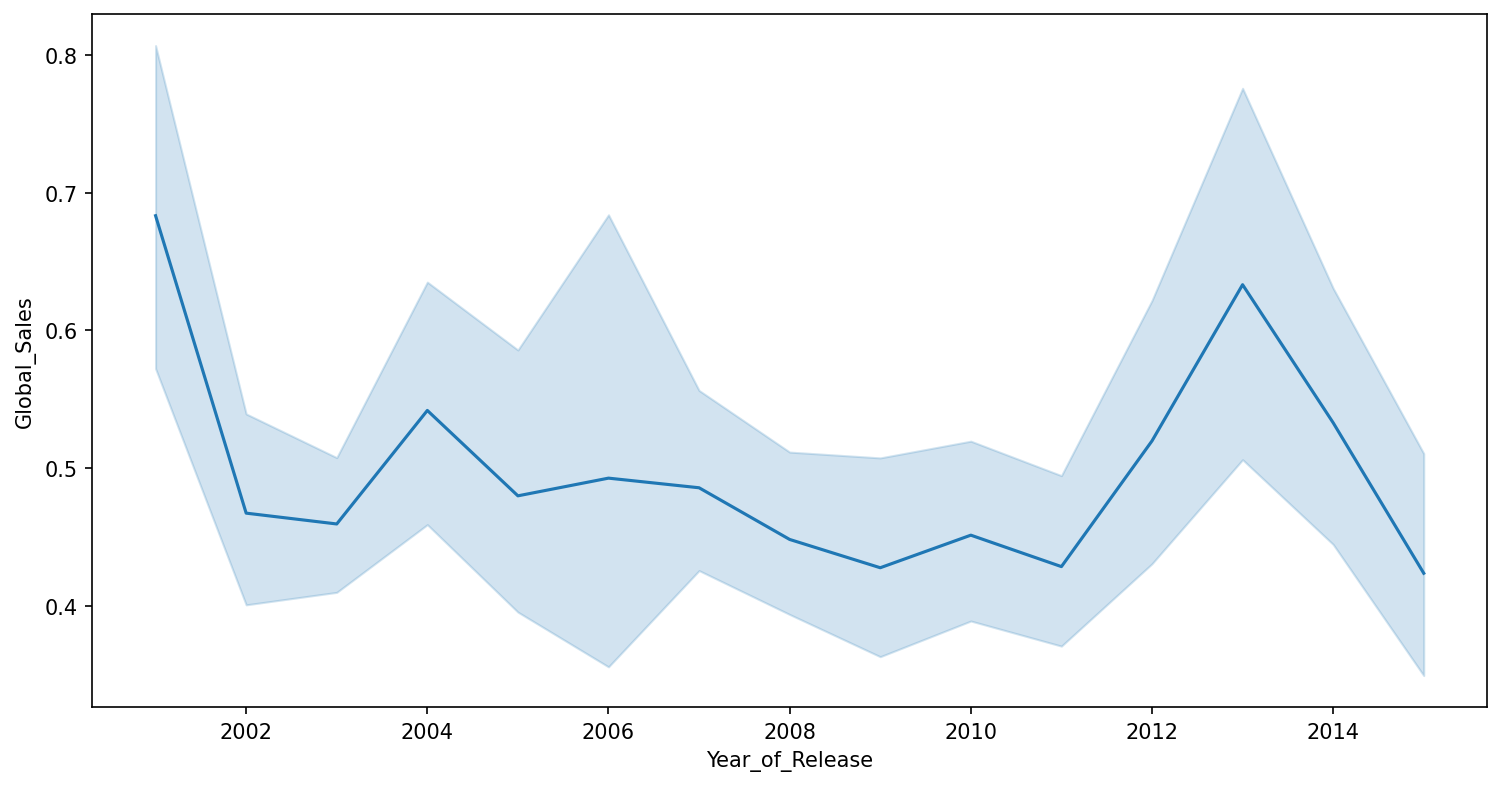

In [ ]:
plt.figure(figsize=(12,6), dpi=150)
sns.lineplot(data=df_eda,
                x="Year_of_Release",
                y="Global_Sales")

plt.show()

Perlu revisi
Insight :

Dari diagram di atas, kita dapat melihat bahwa sebagian besar game menghasilkan penjualan global kurang dari $20 juta.

Beberapa game bahkan memiliki penjualan yang sangat baik sampai melewati angka $20 juta.

### Total Count of Games for each Platform

In [ ]:
platform_counts = df_eda['Platform'].value_counts().reset_index()
platform_counts.columns = ['Platform', 'Total Games']

# Menampilkan tabel hasil perhitungan
display(platform_counts)

,Platform,Total Games
0,DS,2248
1,PS2,2124
2,Wii,1356
3,PS3,1322
4,PSP,1302
5,X360,1283
6,PC,1005
7,GBA,843
8,X,832
9,GC,563


<ipython-input-24-1902ea8b530a>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda,


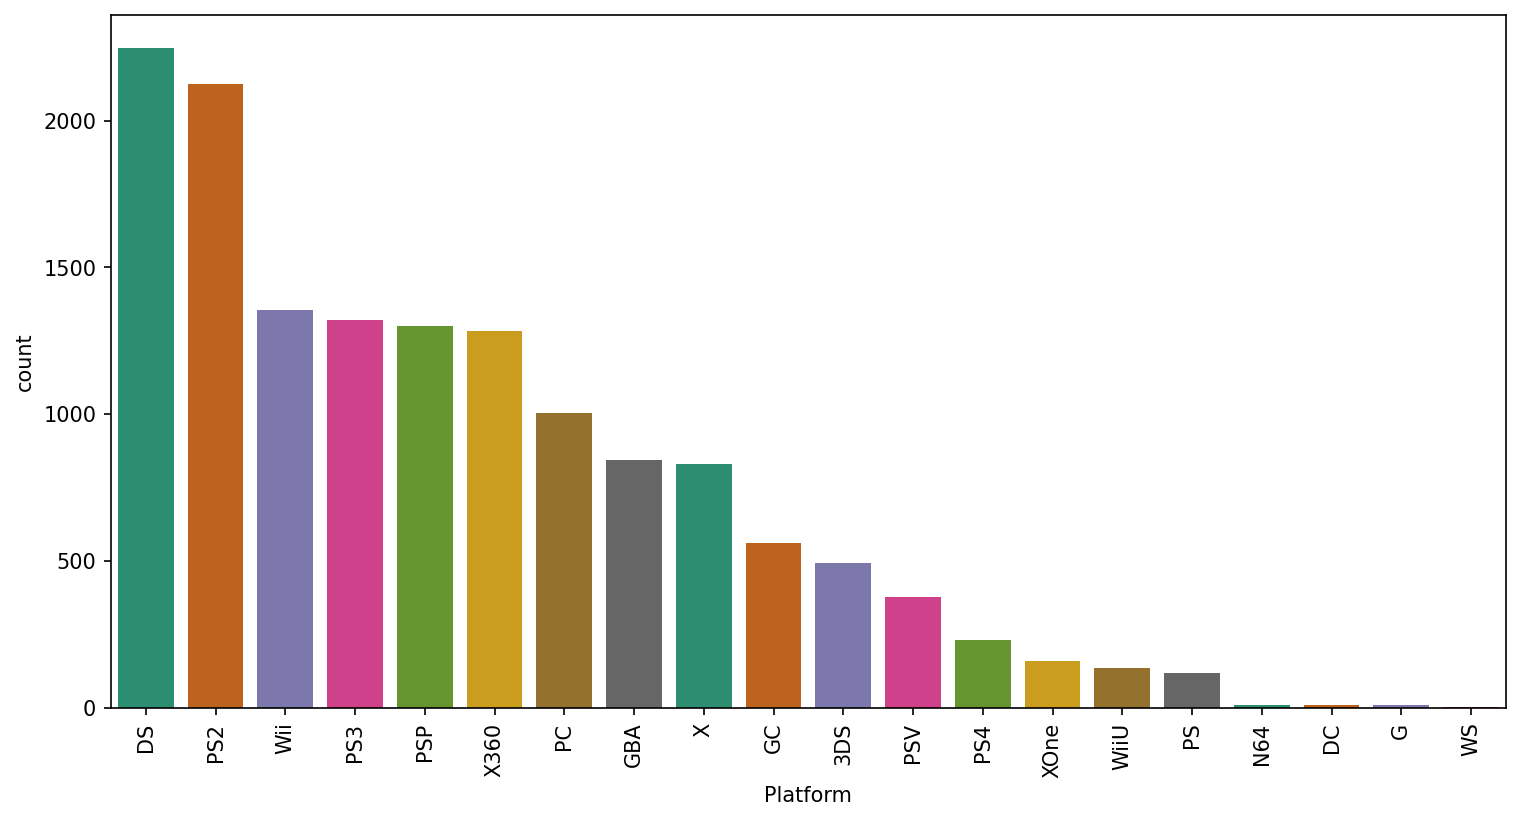

In [ ]:
plt.figure(figsize=(12,6), dpi=150)
sns.countplot(data=df_eda,
              x="Platform",
              order = df_eda["Platform"].value_counts().index,
              palette="Dark2")
plt.xticks(rotation=90)
plt.show()

Insight :

PS 2 dan DS memiliki jenis permainan terbanyak, sedangkan DC memiliki jenis permainan paling kecil di ikuti dengan PS.

###Total Count of Games for each Genre

In [ ]:
genre_counts = df_eda['Genre'].value_counts().reset_index()
genre_counts.columns = ['Genre', 'Total Games']

# Menampilkan tabel hasil perhitungan
display(genre_counts)

,Genre,Total Games
0,Action,3003
1,Sports,1945
2,Misc,1623
3,Role-Playing,1268
4,Adventure,1267
5,Shooter,1111
6,Racing,1018
7,Simulation,798
8,Platform,697
9,Fighting,618


<ipython-input-26-8ce6e4747a72>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda,


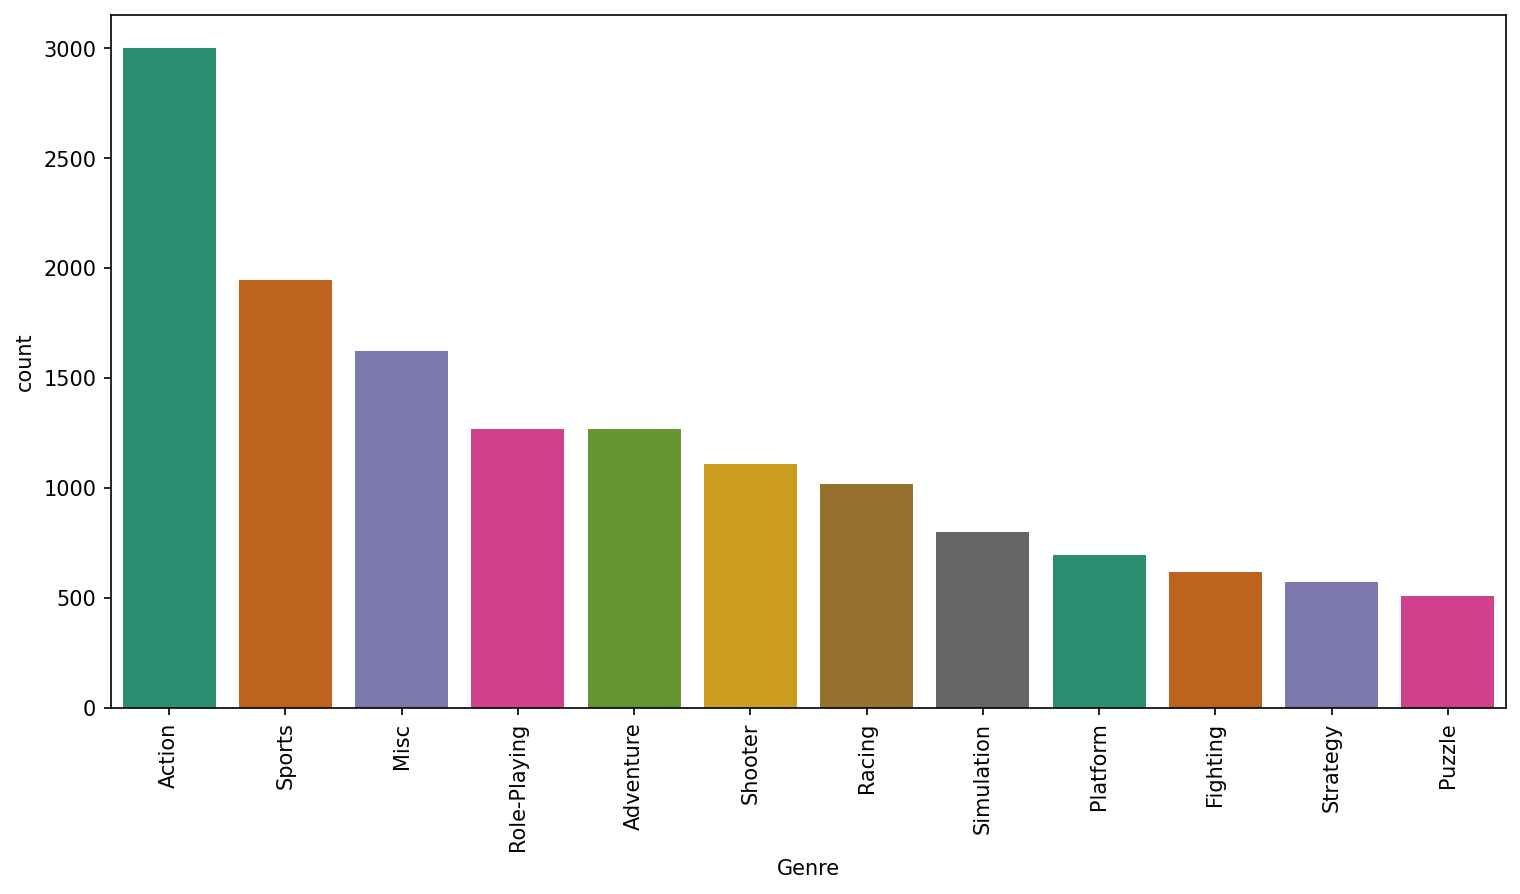

In [ ]:
plt.figure(figsize=(12,6), dpi=150)
sns.countplot(data=df_eda,
              x="Genre",
              order = df_eda["Genre"].value_counts().index,
              palette="Dark2")
plt.xticks(rotation=90)
plt.show()

Insight :

Action menjadi genre yang paling banyak ditemukan dalam judul game, di ikuti oleh Sports, dan Misc. Puzzle sepertinya menjadi gendre paling tidak populer di kalangan pengembang game.

### Genre Sales by Region

In [ ]:
selected_columns = ['Genre', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
df_selected = df_eda[selected_columns]

# Group by genre and sum the sales for each region
df_genre_sales = df_selected.groupby('Genre').sum()

# Menampilkan tabel hasil penjualan per genre
display(df_genre_sales)

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,740.79,455.70,123.42,173.68
Adventure,83.23,48.22,36.21,14.48
Fighting,152.22,68.39,41.57,30.56
Misc,366.63,194.46,83.03,71.69
Platform,249.36,135.37,52.80,40.34
Puzzle,63.45,39.18,23.91,10.03
Racing,263.11,186.23,26.76,68.08
Role-Playing,271.54,149.15,221.84,48.91
Shooter,480.89,279.42,22.24,95.83


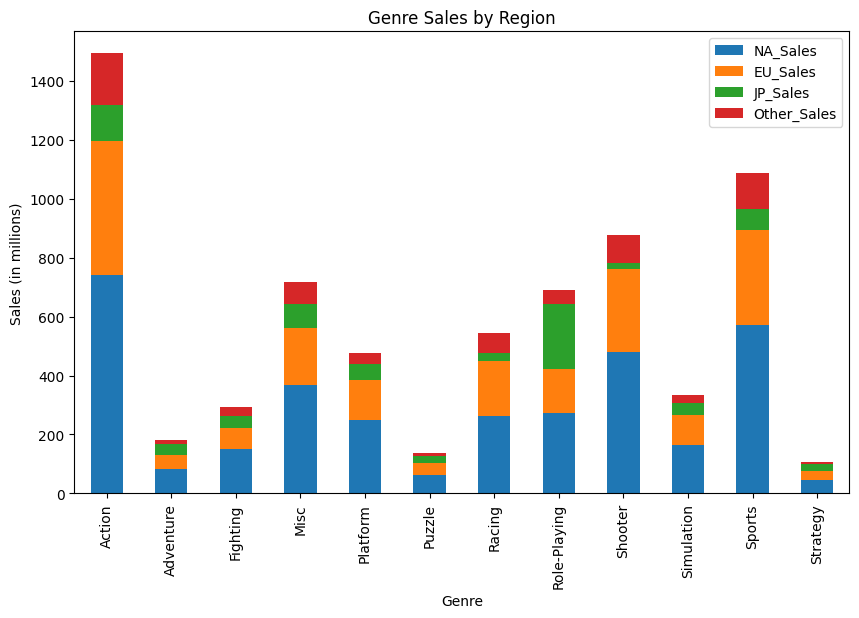

In [ ]:
selected_columns = ['Genre', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
df_selected = df_eda[selected_columns]

# Group by genre and sum the sales for each region
df_genre_sales = df_selected.groupby('Genre').sum()

# Plot histogram
df_genre_sales.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Genre Sales by Region')
plt.xlabel('Genre')
plt.ylabel('Sales (in millions)')
plt.legend(loc='upper right')
plt.show()

###Top 5 games making the most sales globally

In [ ]:
df_eda.nlargest(5, "Global_Sales")

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
4919,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.54,76,51,8,324,E
7108,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.80,3.79,3.29,35.57,82,73,8,712,E
9244,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.95,3.28,2.95,32.78,80,73,8,193,E
4363,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.28,9.15,6.50,2.88,29.81,89,65,8,433,E
4327,Wii Play,Wii,2006,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58,41,6,129,E


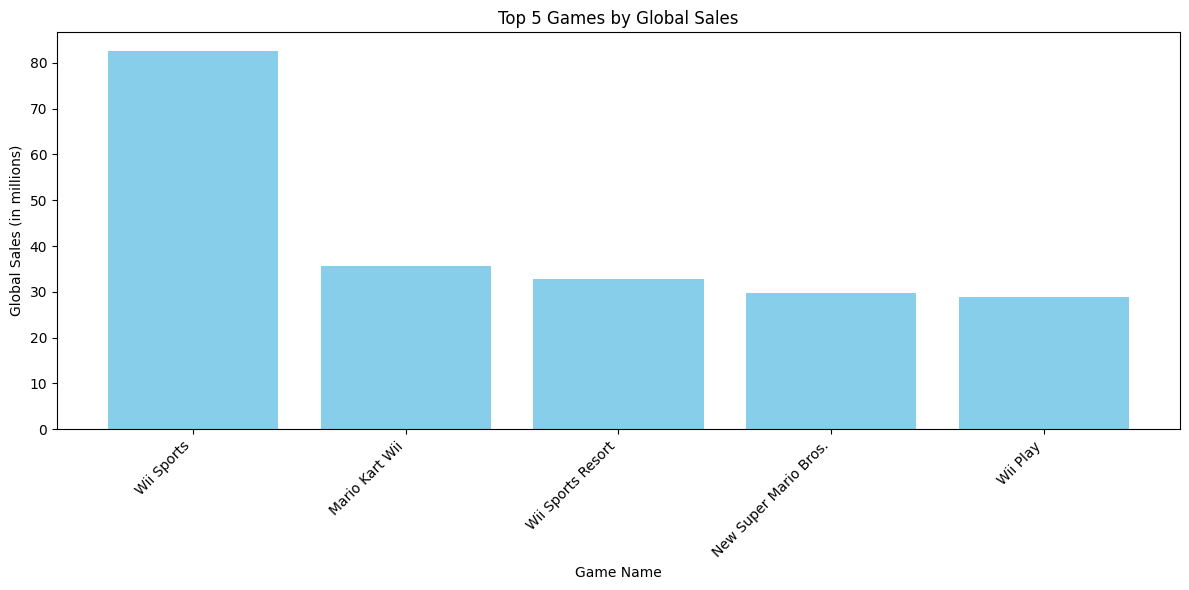

In [ ]:
top_5_games = df_eda.nlargest(5, "Global_Sales")

# Buat bar chart
plt.figure(figsize=(12, 6))
plt.bar(top_5_games["Name"], top_5_games["Global_Sales"], color='skyblue')
plt.xlabel('Game Name')
plt.ylabel('Global Sales (in millions)')
plt.title('Top 5 Games by Global Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Top 5 gaming Genres that are making high sales

In [ ]:
sales_genre = df_eda.groupby("Genre").agg({"Global_Sales": pd.Series.sum})
sales_genre.nlargest(5, "Global_Sales")

,Global_Sales
Genre,
Action,1494.42
Sports,1088.25
Shooter,878.77
Misc,716.53
Role-Playing,691.46


<ipython-input-33-eb822a4cb2a7>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Genre", y="Global_Sales", data=top_5_genres, palette="viridis")


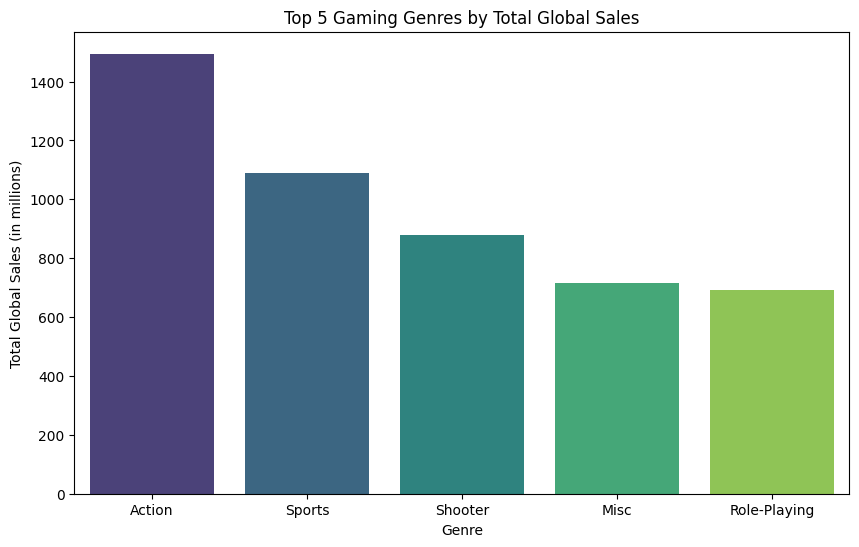

In [ ]:
# Group the data by Genre and sum the Global_Sales for each genre
sales_genre = df_eda.groupby("Genre").agg({"Global_Sales": "sum"}).reset_index()

# Sort the data by Global_Sales in descending order and take the top 5 genres
top_5_genres = sales_genre.nlargest(5, "Global_Sales")

# Create a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x="Genre", y="Global_Sales", data=top_5_genres, palette="viridis")
plt.xlabel('Genre')
plt.ylabel('Total Global Sales (in millions)')
plt.title('Top 5 Gaming Genres by Total Global Sales')
plt.show()

### Game made the most sales per region

In [ ]:
# Mendapatkan game dengan penjualan tertinggi di setiap wilayah
top_game_na = df_eda.loc[df_eda['NA_Sales'].idxmax()]
top_game_eu = df_eda.loc[df_eda['EU_Sales'].idxmax()]
top_game_jp = df_eda.loc[df_eda['JP_Sales'].idxmax()]
top_game_other = df_eda.loc[df_eda['Other_Sales'].idxmax()]

# Menampilkan hasil
print("Game with the most sales in each region:")
print(f"NA: {top_game_na['Name']} - {top_game_na['NA_Sales']} million ")
print(f"EU: {top_game_eu['Name']} - {top_game_eu['EU_Sales']} million ")
print(f"JP: {top_game_jp['Name']} - {top_game_jp['JP_Sales']} million ")
print(f"Other: {top_game_other['Name']} - {top_game_other['Other_Sales']} million ")

Game with the most sales in each region:
NA: Wii Sports - 41.36 million 
EU: Wii Sports - 28.96 million 
JP: New Super Mario Bros. - 6.5 million 
Other: Grand Theft Auto: San Andreas - 10.57 million 


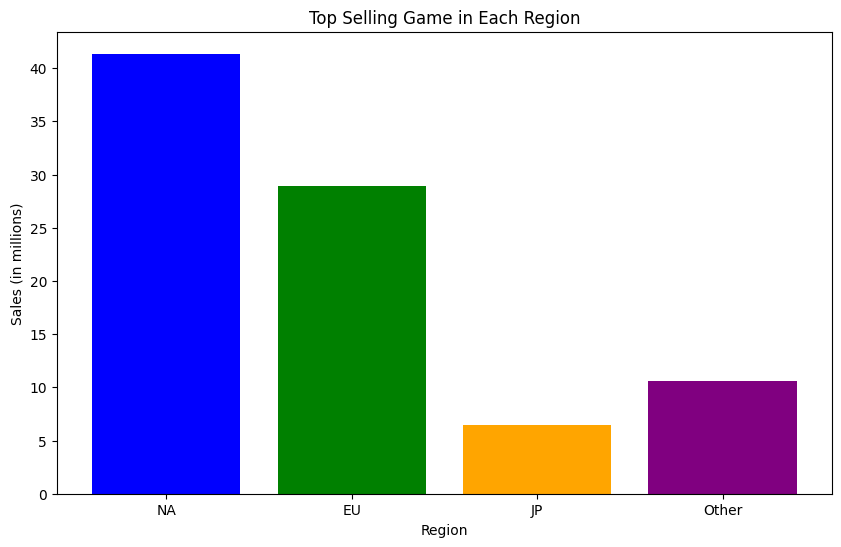

In [ ]:
# Data untuk chart
regions = ['NA', 'EU', 'JP', 'Other']
sales = [top_game_na['NA_Sales'], top_game_eu['EU_Sales'], top_game_jp['JP_Sales'], top_game_other['Other_Sales']]

# Buat bar chart
plt.figure(figsize=(10, 6))
plt.bar(regions, sales, color=['blue', 'green', 'orange', 'purple'])
plt.xlabel('Region')
plt.ylabel('Sales (in millions)')
plt.title('Top Selling Game in Each Region')
plt.show()

### Publisher made most sales

In [ ]:
sales_publisher = df_eda.groupby("Publisher").agg({"Global_Sales": pd.Series.sum})
sales_publisher.nlargest(5, "Global_Sales")

,Global_Sales
Publisher,
Nintendo,1150.20
Electronic Arts,986.51
Activision,663.29
Ubisoft,447.78
Sony Computer Entertainment,408.50


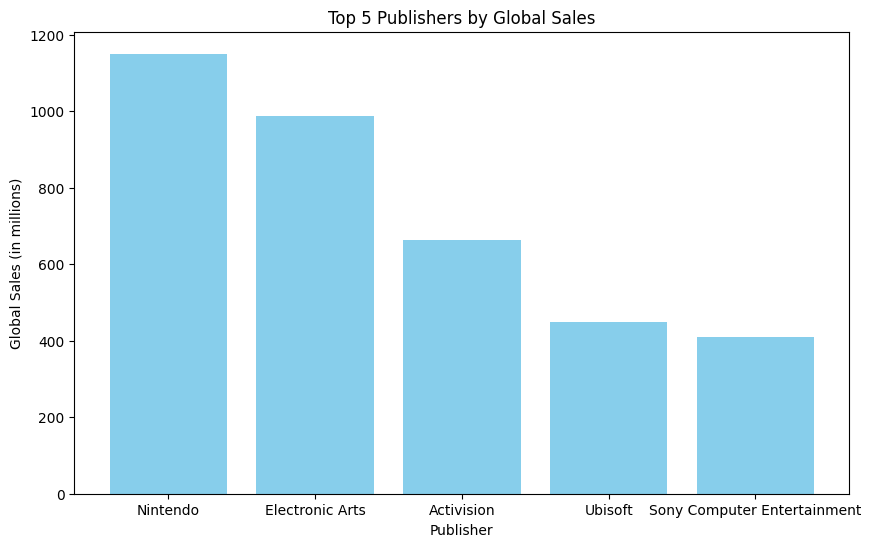

In [ ]:
sales_publisher = df_eda.groupby("Publisher").agg({"Global_Sales": pd.Series.sum})

# Mengambil 5 penerbit dengan penjualan global tertinggi
top_publishers = sales_publisher.nlargest(5, "Global_Sales")

# Membuat bar chart
plt.figure(figsize=(10, 6))
plt.bar(top_publishers.index, top_publishers["Global_Sales"], color='skyblue')
plt.xlabel('Publisher')
plt.ylabel('Global Sales (in millions)')
plt.title('Top 5 Publishers by Global Sales')
plt.show()

## Analysis Trend of sales


### Analysis of Sales Trend from year to year

In [ ]:
df_eda['Year'] = pd.to_datetime(df_eda['Year_of_Release'], format='%Y').dt.year

# Menghitung total penjualan global untuk setiap tahun
sales_per_year = df_eda.groupby('Year')['Global_Sales'].sum().reset_index()

# Menampilkan tabel
print(sales_per_year)

    Year  Global_Sales
0   2001        335.49
1   2002        406.01
2   2003        367.94
3   2004        422.08
4   2005        464.44
5   2006        525.65
6   2007        612.89
7   2008        688.29
8   2009        662.71
9   2010        600.57
10  2011        520.48
11  2012        358.07
12  2013        365.34
13  2014        338.38
14  2015        278.27


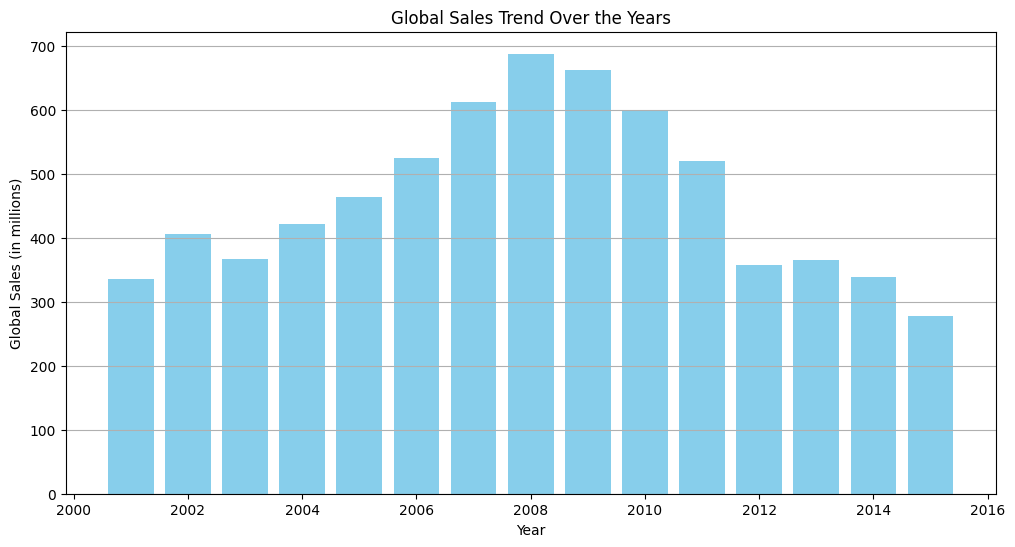

In [ ]:
# Membuat bar chart
plt.figure(figsize=(12, 6))
plt.bar(sales_per_year['Year'], sales_per_year['Global_Sales'], color='skyblue')
plt.title('Global Sales Trend Over the Years')
plt.xlabel('Year')
plt.ylabel('Global Sales (in millions)')
plt.grid(axis='y')
plt.show()


### Sales Trend Analysis per Region

In [ ]:
df_eda['Year'] = pd.to_datetime(df_eda['Year_of_Release'], format='%Y').dt.year

# Menghitung total penjualan per wilayah untuk setiap tahun
sales_per_year_region = df_eda.groupby(['Year'])[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

# Menampilkan tabel
print(sales_per_year_region)

      NA_Sales  EU_Sales  JP_Sales  Other_Sales
Year                                           
2001    177.26     95.44     39.86        22.91
2002    222.21    112.82     42.31        28.09
2003    199.19    106.62     34.66        27.17
2004    223.94    107.90     42.42        47.40
2005    245.92    122.69     54.47        40.83
2006    265.95    129.66     74.97        54.41
2007    314.46    159.42     60.52        77.79
2008    357.07    185.41     62.33        83.10
2009    337.58    188.55     62.73        73.73
2010    305.84    174.11     60.51        59.45
2011    244.86    167.77     53.46        54.18
2012    153.88    115.47     52.21        36.39
2013    154.90    123.58     48.23        38.82
2014    135.19    125.24     40.36        37.62
2015    111.76     99.92     35.07        31.46


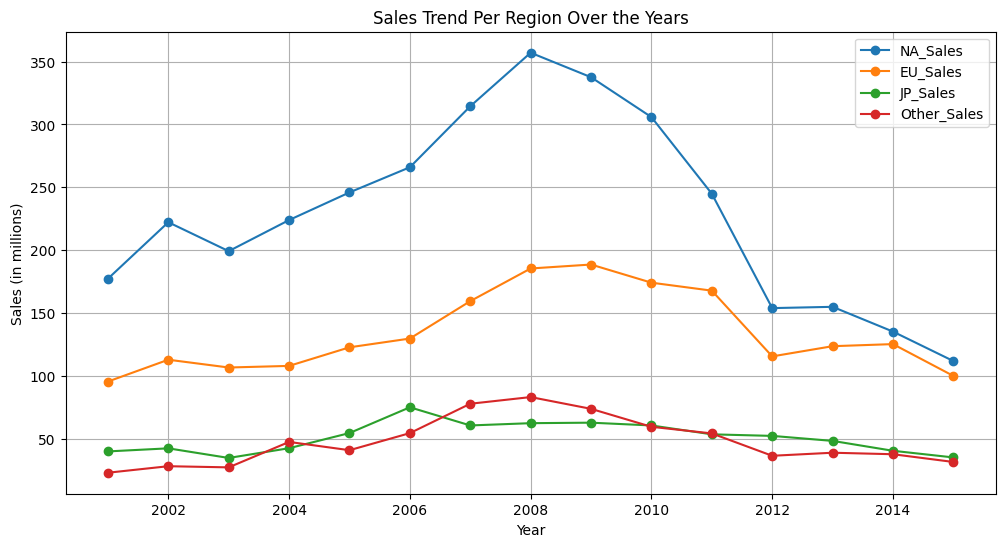

In [ ]:
df_eda['Year'] = pd.to_datetime(df_eda['Year_of_Release'], format='%Y').dt.year

# Menghitung total penjualan per wilayah untuk setiap tahun
sales_per_year_region = df_eda.groupby(['Year'])[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

# Membuat line chart untuk menampilkan tren penjualan per wilayah dari tahun ke tahun
plt.figure(figsize=(12, 6))
for region in sales_per_year_region.columns:
    plt.plot(sales_per_year_region.index, sales_per_year_region[region], marker='o', linestyle='-', label=region)

plt.title('Sales Trend Per Region Over the Years')
plt.xlabel('Year')
plt.ylabel('Sales (in millions)')
plt.legend()
plt.grid(True)
plt.show()


### Sales Trend Analysis per Genre

In [ ]:
df_eda['Year'] = pd.to_datetime(df_eda['Year_of_Release'], format='%Y').dt.year

# Menghitung total penjualan per genre untuk setiap tahun
sales_per_year_genre = df_eda.groupby(['Year', 'Genre'])['Global_Sales'].sum().unstack()

# Menampilkan tabel
print(sales_per_year_genre)

Genre  Action  Adventure  Fighting   Misc  Platform  Puzzle  Racing  \
Year                                                                  
2001    59.57      11.68     18.12  16.68     39.28    8.00   55.81   
2002    89.11      11.06     25.15  16.74     46.26    5.35   32.38   
2003    68.01       2.15     23.93  23.82     42.89    2.64   52.24   
2004    76.61       8.70     17.56  31.32     47.26    9.15   47.83   
2005    86.61       8.52     22.73  61.11     23.58   20.42   56.07   
2006    66.74      11.42     22.80  67.38     49.97   10.85   33.96   
2007   106.34      24.16     17.51  96.85     35.13   23.83   38.92   
2008   143.70      24.95     35.21  89.50     35.19   15.35   70.24   
2009   137.91      20.70     32.02  76.21     40.68   19.91   33.71   
2010   116.83      16.38     14.75  96.48     31.13   11.45   34.74   
2011   124.16      15.78     22.40  55.25     27.81    5.08   36.91   
2012   119.61       5.82      9.25  22.31     18.63    1.81   13.75   
2013  

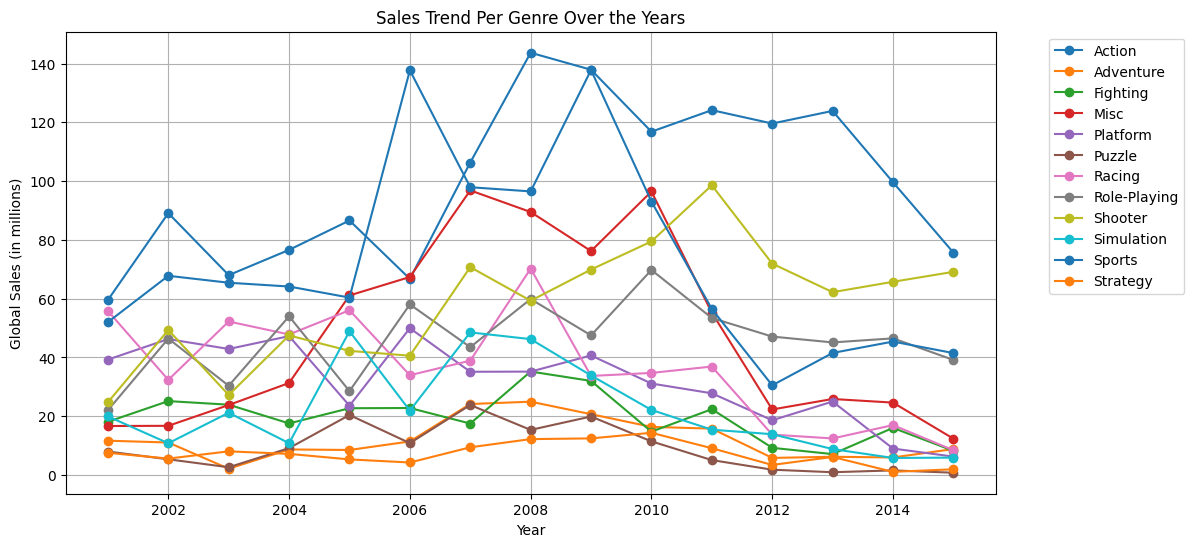

In [ ]:
sales_per_year_genre = df_eda.groupby(['Year', 'Genre'])['Global_Sales'].sum().unstack()

# Membuat line chart untuk menampilkan tren penjualan per genre dari tahun ke tahun
plt.figure(figsize=(12, 6))
for genre in sales_per_year_genre.columns:
    plt.plot(sales_per_year_genre.index, sales_per_year_genre[genre], marker='o', linestyle='-', label=genre)

plt.title('Sales Trend Per Genre Over the Years')
plt.xlabel('Year')
plt.ylabel('Global Sales (in millions)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


### Calculates total sales per ESRB rating for each year

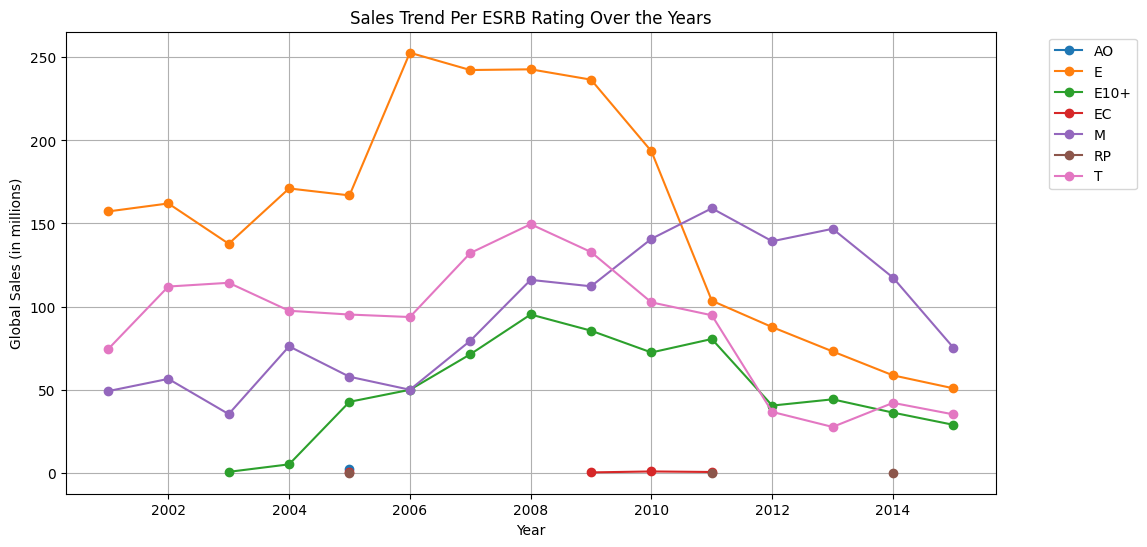

In [ ]:
# Menghitung total penjualan per rating ESRB untuk setiap tahun
sales_per_year_rating = df_eda.groupby(['Year', 'Rating'])['Global_Sales'].sum().unstack()

# Membuat line chart untuk menampilkan tren penjualan per rating ESRB dari tahun ke tahun
plt.figure(figsize=(12, 6))
for rating in sales_per_year_rating.columns:
    plt.plot(sales_per_year_rating.index, sales_per_year_rating[rating], marker='o', linestyle='-', label=rating)

plt.title('Sales Trend Per ESRB Rating Over the Years')
plt.xlabel('Year')
plt.ylabel('Global Sales (in millions)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

Insight :

Rating yang diberikan oleh ESRB mencakup beberapa kategori, termasuk:

* EC (Early Childhood): Cocok untuk anak-anak pra-sekolah.
* E (Everyone): Cocok untuk semua usia.
* E10+ (Everyone 10 and older): Cocok untuk semua usia 10 tahun ke atas.
* T (Teen): Cocok untuk remaja 13 tahun ke atas.
* M (Mature): Cocok untuk 17 tahun ke atas.
* AO (Adults Only): Cocok hanya untuk orang dewasa yang berusia 18 tahun ke atas.

In [ ]:
df_eda.shape

(14427, 15)